# MACH 04 · R–v phase-space diagrams

Cluster-centric velocity vs. projected radius of the galaxies with a redshift in each MACH cluster, with the caustic envelope (from `DATA/MACH_CAUSTIC/`) that defines membership, and the R200 / R500 radii (Figure 4).

**Inputs** (not included): `DATA/MACH_PHOT/MACH_photcat_3R200.csv`, `DATA/MACH_PHOT/AllHeCS_VAC_updated.csv`, `DATA/MACH_CAUSTIC/<cluster>_caustic.csv`

**Output**: `FIGURE/IMAGES/Figure4.pdf`

In [1]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

In [2]:
# Define file paths
mach_file = f"{MAINPATH}/DATA/MACH_PHOT/MACH_photcat_3R200.csv"
hecs_vac_file = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"

# Load datasets
mach_data = pd.read_csv(mach_file)
hecs_vac_data = pd.read_csv(hecs_vac_file)

# Apply extinction corrections
mach_data['cmodelMag_r_0'] = mach_data['cmodelMag_r'] - mach_data['extinction_r']
mach_data['cmodelMag_g_0'] = mach_data['cmodelMag_g'] - mach_data['extinction_g']

# Objects within 3 R200
df = mach_data.loc[mach_data['Rcl/R200'] <= 3.0].copy()

# 1. Phase-space diagrams of all nine clusters (Figure 4)

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_72609/1546142807.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


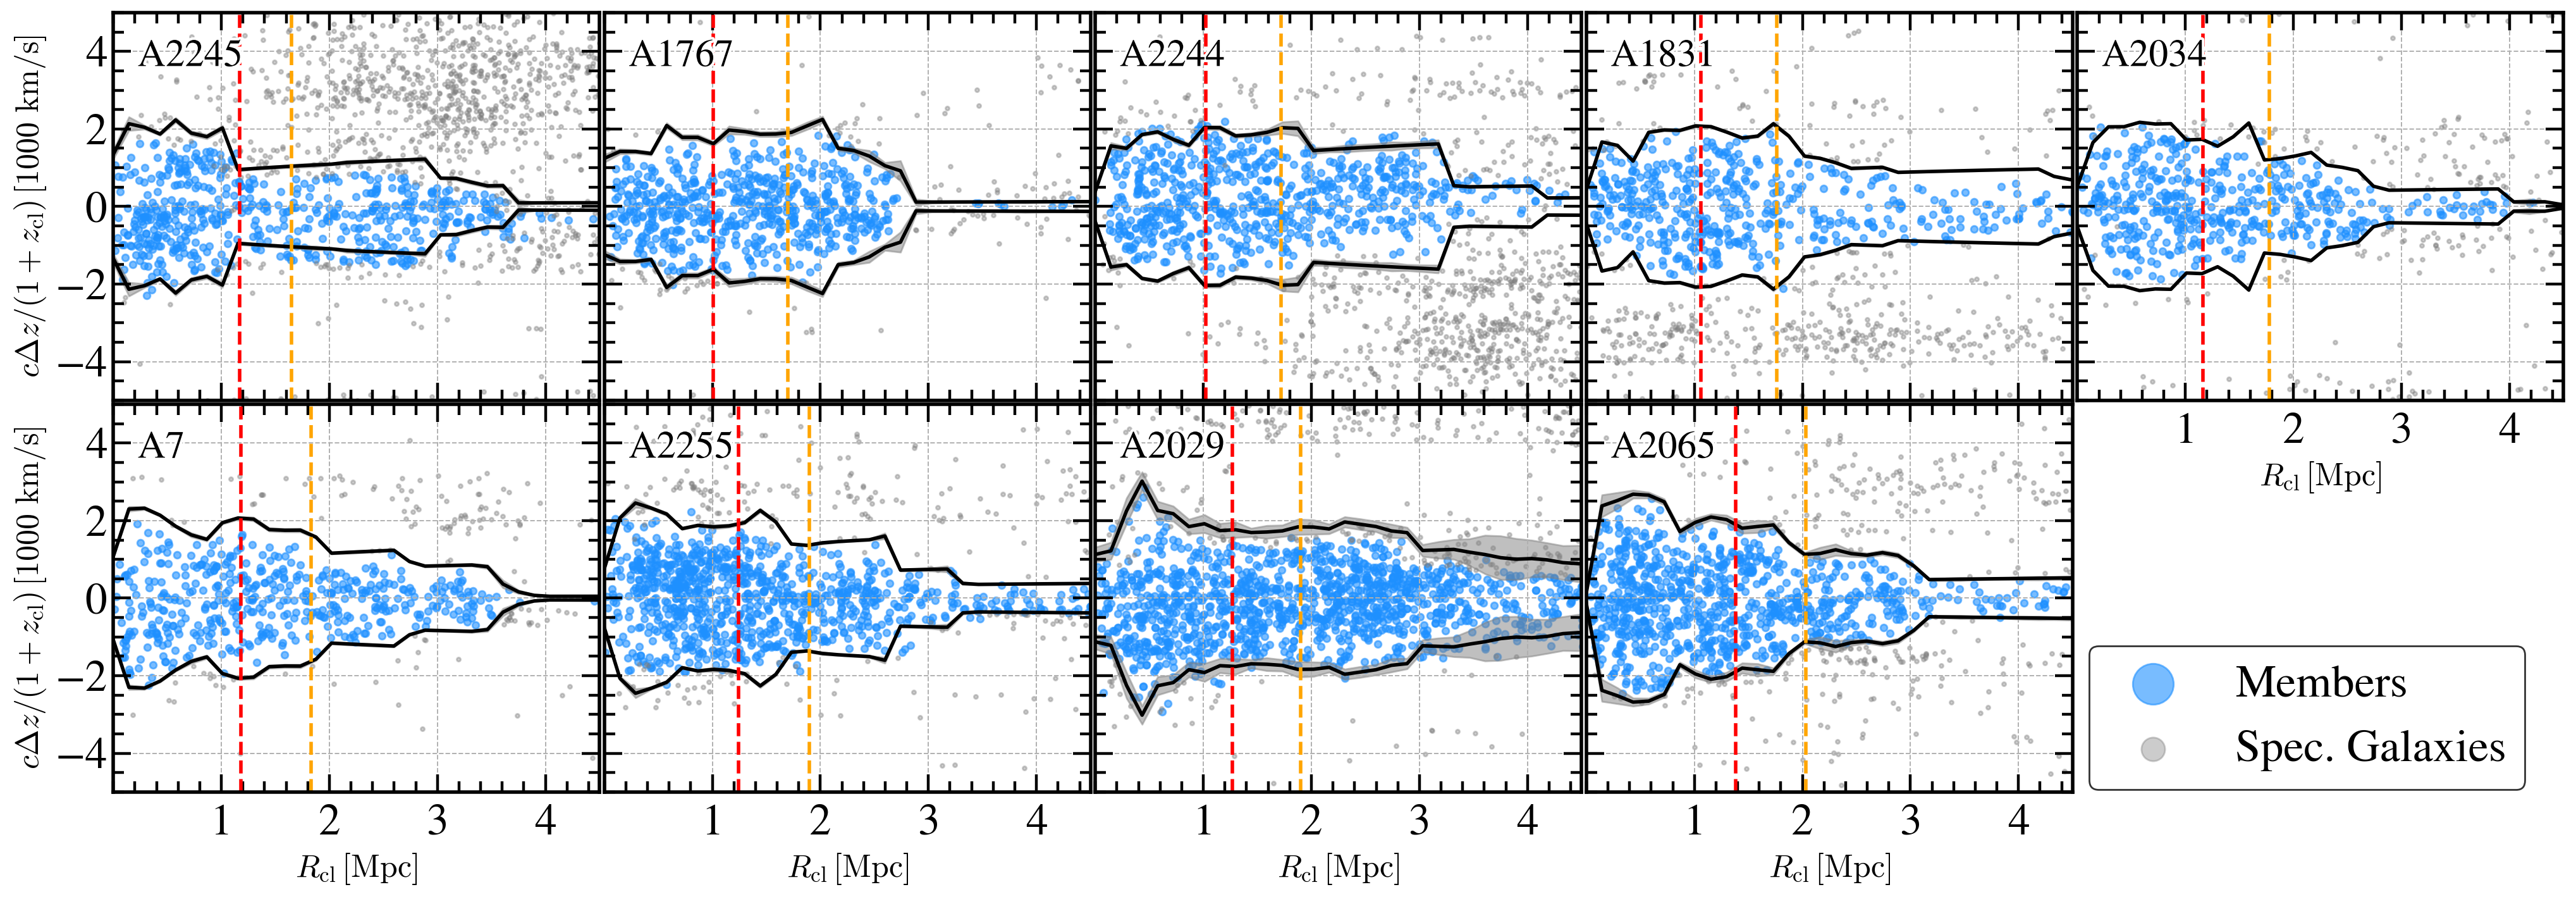

In [3]:
import matplotlib.patheffects as patheffects

# Constants
c = 3e5  # km/s

# Set up the subplot grid (2 rows, 5 columns)
fig, axs = plt.subplots(2, 5, figsize=(25, 8), gridspec_kw={'wspace': 0.01, 'hspace': 0.01})
axs = axs.flatten()

for i, TARGET in enumerate(MACHLIST):
    # Select MACH data for this cluster
    df = mach_data[mach_data['CLID'] == TARGET].copy()
    df = df[df['Z_TOT_Z'] != -99]

    # Load caustic profile for this cluster
    caustic = pd.read_csv(f'{MAINPATH}/DATA/MACH_CAUSTIC/{TARGET}_caustic.csv')
    caustic['delcz'] *= 1e-3
    caustic['delcz_error'] *= 1e-3

    # Cluster parameters from already-loaded hecs_vac_data
    R200   = hecs_vac_data.loc[hecs_vac_data['CLID'] == TARGET, 'R200'].iat[0]
    R500   = hecs_vac_data.loc[hecs_vac_data['CLID'] == TARGET, 'R500'].iat[0]
    Z_CLID = hecs_vac_data.loc[hecs_vac_data['CLID'] == TARGET, 'Z'].iat[0]

    # Calculate rest-frame velocity offsets (1000 km/s)
    df['REL'] = c * (df['Z_TOT_Z'] - Z_CLID) / (1 + Z_CLID) * 1e-3

    ax = axs[i]

    # Plot cluster members
    members = df[df['MEMBER'] == 'Y']
    ax.scatter(members['Rcl_Mpc'], members['REL'],
               s=15, color='dodgerblue', alpha=0.6, label='Members')

    # Plot non-members
    non_members = df[df['MEMBER'] == 'N']
    ax.scatter(non_members['Rcl_Mpc'], non_members['REL'],
               s=5, color='gray', alpha=0.4, label='Spec. Galaxies')

    # Caustic envelope
    ax.plot(caustic['angular_rad'], caustic['delcz'], color='black', lw=2)
    ax.fill_between(
        caustic['angular_rad'],
        caustic['delcz'] - caustic['delcz_error'],
        caustic['delcz'] + caustic['delcz_error'],
        color='gray', alpha=0.5
    )
    ax.plot(caustic['angular_rad'], -caustic['delcz'], color='black', lw=2)
    ax.fill_between(
        caustic['angular_rad'],
        -caustic['delcz'] - caustic['delcz_error'],
        -caustic['delcz'] + caustic['delcz_error'],
        color='gray', alpha=0.5
    )

    # Vertical lines at R500 and R200
    ax.axvline(R500, color='red', linestyle='--', lw=2)
    ax.axvline(R200, color='orange', linestyle='--', lw=2)

    # Axes limits and ticks
    ax.set_xlim(0, 4.5)
    ax.set_ylim(-5, 5)
    ax.set_xticks(np.arange(1, 5, 1))
    ax.set_yticks(np.arange(-4, 5, 2))
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5))

    ax.tick_params(which='both', direction='in', top=True, right=True, labeltop=False, labelright=False)

    # Major grid
    ax.grid(which='major', linestyle='--', linewidth=0.7)

    # Only show y-axis label for leftmost panels
    if i in [0, 5]:
        ax.set_ylabel(r'$c\Delta z/(1+z_{\mathrm{cl}})\,[1000~\mathrm{km/s}]$', fontsize=18)
    else:
        ax.set_yticklabels([])

    # Only show x-axis label for bottom panels
    if i >= 4:
        ax.set_xlabel(r'$R_{\mathrm{cl}}\,[\mathrm{Mpc}]$', fontsize=18)
    else:
        ax.set_xticklabels([])

    # Cluster ID title
    ax.text(0.05, 0.93, TARGET, transform=ax.transAxes,
            fontsize=22, ha='left', va='top',
            path_effects=[patheffects.withStroke(linewidth=3, foreground='w')])

    # Thicker box borders
    for spine in ax.spines.values():
        spine.set_linewidth(2)

# Hide any unused subplots
for j in range(len(MACHLIST), len(axs)):
    fig.delaxes(axs[j])

# Add legend once for all panels
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.895, 0.09),
    loc='lower right',
    ncol=1,
    fontsize=26,
    frameon=True,
    edgecolor='black',
    markerscale=6
)

# Save and show the figure
plt.tight_layout()
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure4.pdf", format="pdf", bbox_inches="tight")
plt.show()

# 2. Single-cluster version with an angular axis (for presentations)

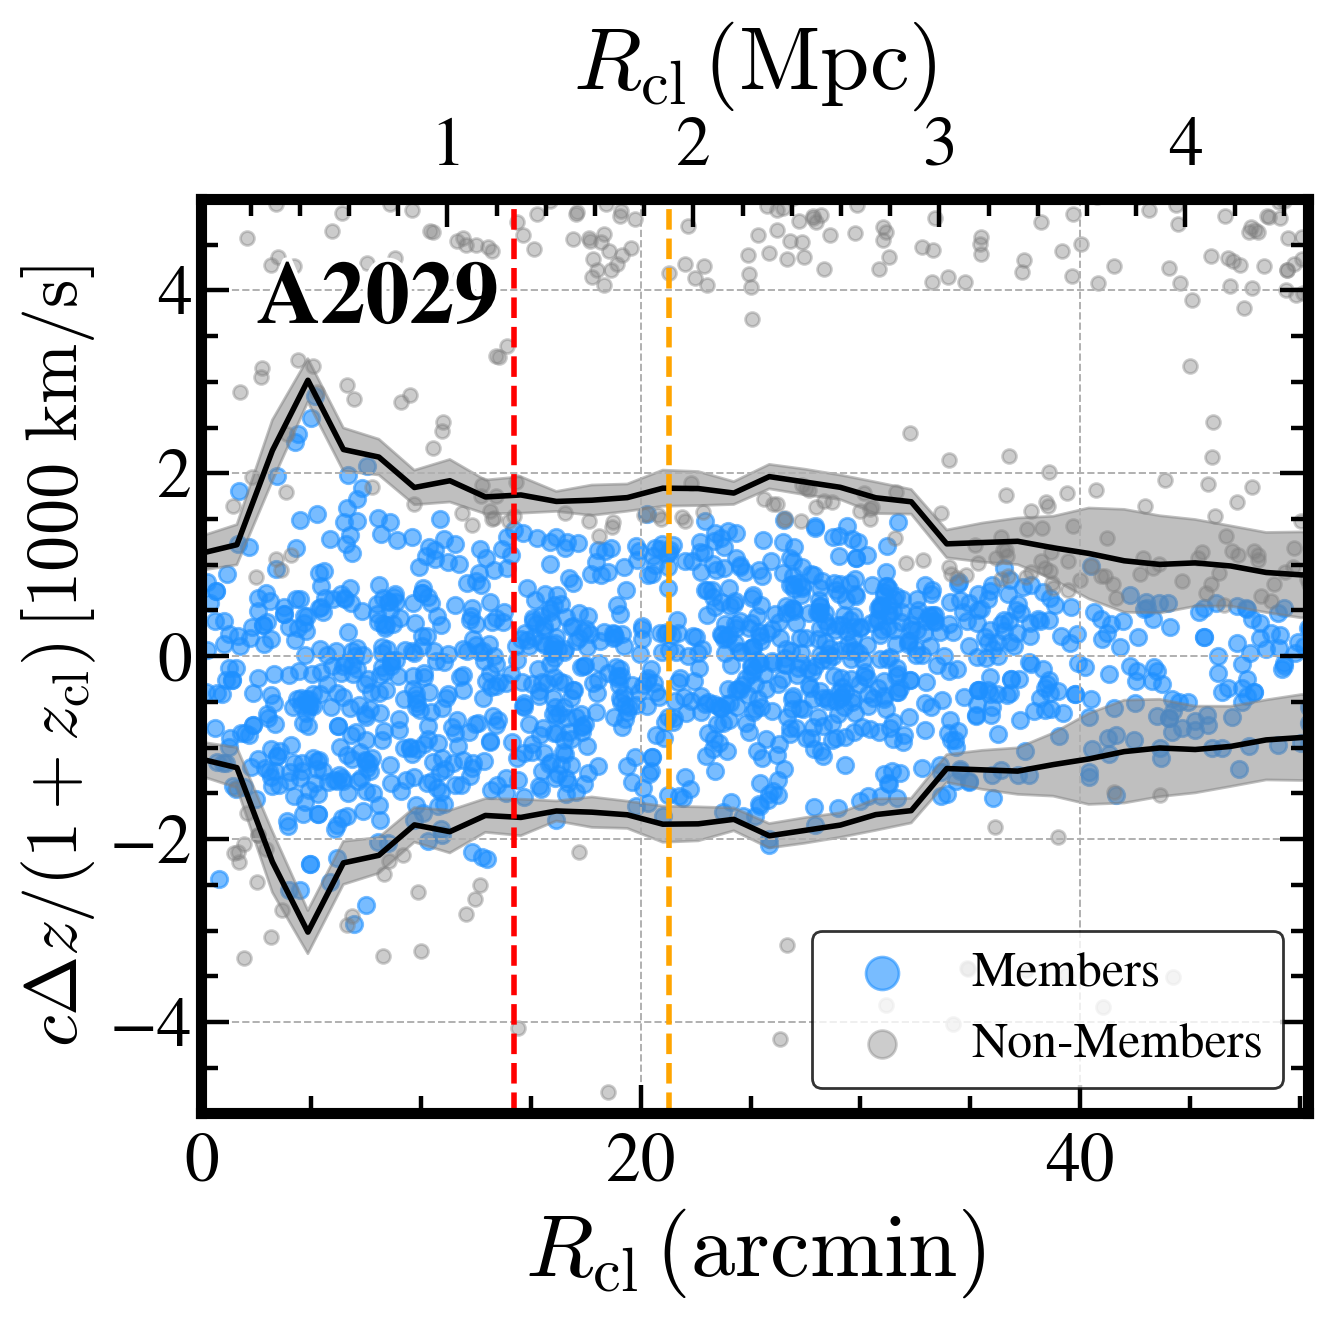

In [4]:
import matplotlib.patheffects as patheffects
import astropy.units as u

# --- CONSTANTS ---
c = 3e5  # Speed of light in km/s

# --- LOAD DATA ---

# Load HeCS VAC cluster properties for cluster IDs, R200, R500, redshifts, etc.
hecs_vac = pd.read_csv(f'{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv')

# Set up plotting for a single cluster diagram
fig, ax = plt.subplots(figsize=(7.2, 7.2))  # 9*0.8 = 7.2

TARGET = 'A2029'  # Target cluster name

# Subset the MACH data for this cluster and filter valid redshift objects
df = mach_data[mach_data['CLID'] == TARGET].copy()
df = df[df['Z_TOT_Z'] != -99]

# Load caustic profile for this cluster
caustic = pd.read_csv(f'{MAINPATH}/DATA/MACH_CAUSTIC/{TARGET}_caustic.csv')
caustic['delcz'] *= 1e-3         # convert caustic profile from km/s to 1000 km/s
caustic['delcz_error'] *= 1e-3   # convert error bars to 1000 km/s

# Cluster global properties from HECS VAC catalog
R200_mpc = hecs_vac.loc[hecs_vac['CLID'] == TARGET, 'R200'].iat[0]
R500_mpc = hecs_vac.loc[hecs_vac['CLID'] == TARGET, 'R500'].iat[0]
Z_CLID   = hecs_vac.loc[hecs_vac['CLID'] == TARGET, 'Z'].iat[0]

# --- ANGULAR CONVERSION SETUP ---

# Compute angular diameter distance to the cluster
d_a = cosmo.angular_diameter_distance(Z_CLID)

# Conversion function: Mpc -> arcmin
def mpc_to_arcmin(r_mpc):
    """Convert distance r [Mpc] to angular scale [arcmin] at z."""
    angle_rad = (r_mpc * u.Mpc / d_a).value * u.rad
    return angle_rad.to(u.arcmin).value

# Conversion function: arcmin -> Mpc
def arcmin_to_mpc(r_arcmin):
    """Convert angular scale [arcmin] to physical [Mpc] at z."""
    angle_rad = (r_arcmin * u.arcmin).to(u.rad)
    return (angle_rad.value * d_a).to(u.Mpc).value

# Apply conversion: Add columns with arcmin units for plotting
df['Rcl_arcmin']                = df['Rcl_Mpc'].apply(mpc_to_arcmin)
caustic['angular_rad_arcmin']   = caustic['angular_rad'].apply(mpc_to_arcmin)
R200_arcmin                     = mpc_to_arcmin(R200_mpc)
R500_arcmin                     = mpc_to_arcmin(R500_mpc)

# Calculate rest-frame velocity offsets (in units of 1000 km/s)
df['REL'] = c * (df['Z_TOT_Z'] - Z_CLID) / (1 + Z_CLID) * 1e-3

# --- PLOTTING ---

# Plot members with blue, non-members with gray
ax.scatter(df[df['MEMBER'] == 'Y']['Rcl_arcmin'],
           df[df['MEMBER'] == 'Y']['REL'],
           s=35, color='dodgerblue', alpha=0.6, label='Members')

ax.scatter(df[df['MEMBER'] == 'N']['Rcl_arcmin'],
           df[df['MEMBER'] == 'N']['REL'],
           s=25, color='gray', alpha=0.4, label='Non-Members')

# Overplot caustic lines (both positive and negative) and their error bands
ax.plot(caustic['angular_rad_arcmin'], caustic['delcz'], color='black', lw=2)
ax.fill_between(caustic['angular_rad_arcmin'],
                caustic['delcz'] - caustic['delcz_error'],
                caustic['delcz'] + caustic['delcz_error'],
                color='gray', alpha=0.5)
ax.plot(caustic['angular_rad_arcmin'], -caustic['delcz'], color='black', lw=2)
ax.fill_between(caustic['angular_rad_arcmin'],
                -caustic['delcz'] - caustic['delcz_error'],
                -caustic['delcz'] + caustic['delcz_error'],
                color='gray', alpha=0.5)

# Mark R500 and R200 with vertical dashed lines
ax.axvline(R500_arcmin, color='red',    linestyle='--', lw=2)
ax.axvline(R200_arcmin, color='orange', linestyle='--', lw=2)

# X-axis (arcmin) and Y-axis (rest-frame velocity) formatting
ax.set_xlim(0, mpc_to_arcmin(4.5))
ax.set_ylim(-5, 5)
ax.set_yticks(np.arange(-4, 5, 2))
# ax.xaxis.set_minor_locator(MultipleLocator(0.2))  # Uncomment to use minor ticks
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
ax.tick_params(which='both', direction='in', top=True, right=True, labeltop=False, labelright=False)

ax.grid(which='major', linestyle='--', linewidth=0.7)

ax.set_ylabel(r'$c\Delta z/(1+z_{\mathrm{cl}})\,[1000~\mathrm{km/s}]$', fontsize=26)
ax.set_xlabel(r'$R_{\mathrm{cl}}\,(\mathrm{arcmin})$', fontsize=32)

# Second X-axis (top, in Mpc)
ax2 = ax.twiny()
arcmin_min, arcmin_max = ax.get_xlim()
ax2.set_xlim(arcmin_to_mpc(arcmin_min), arcmin_to_mpc(arcmin_max))
ax2.set_xlabel(r'$R_{\mathrm{cl}}\,(\mathrm{Mpc})$', fontsize=32, labelpad=10)
ax2.set_xticks(np.arange(1, 5, 1))
ax2.tick_params(which='both', direction='in')

# Annotate Cluster ID in upper-left
ax.text(0.05, 0.93, TARGET, transform=ax.transAxes,
        fontsize=32, ha='left', va='top', fontweight='bold',
        path_effects=[patheffects.withStroke(linewidth=3, foreground='w')])

# Thicken all panel borders
for spine in ax.spines.values():
    spine.set_linewidth(3.5)

# Add legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower right', ncol=1, fontsize=18,
          frameon=True, edgecolor='black', markerscale=2)

# Final layout and show plot
plt.tight_layout()
# plt.savefig(f"{FIGUREPATH}/A2065_Rv_diagram.pdf", format="pdf", bbox_inches="tight")
plt.show()